In [ ]:
print("="*80)
print("IAQ PROJECT - MODEL TRAINING")
print("="*80)
print("Model: LightGBM")
print("Team Member: Aya")
print("="*80)

IAQ PROJECT - MODEL TRAINING
Model: LightGBM
Team Member: Aya


In [ ]:
## **📱 CELL 2: Import Libraries**

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import os
import joblib

warnings.filterwarnings('ignore')


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from lightgbm import LGBMClassifier

MODEL_NAME = "LightGBM"
MODEL_SHORT = "LGBM"

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully!")
print(f"📊 Model: {MODEL_NAME}")

✅ Libraries imported successfully!
📊 Model: LightGBM


In [ ]:
## **📱 CELL 3: Load Data**

print("\n" + "="*80)
print("LOADING DATA")
print("="*80)


X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

print(f"✅ Data loaded successfully!")
print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test: {y_test.shape}")



LOADING DATA
✅ Data loaded successfully!
   X_train: (115200, 10)
   X_test: (28800, 10)
   y_train: (115200,)
   y_test: (28800,)


In [ ]:
## **📱 CELL 4: Explore Data**

print("\n" + "="*80)
print("DATA EXPLORATION")
print("="*80)

print(f"\n📊 Class Distribution (Training):")
print(y_train.value_counts().sort_index())
print(f"\nPercentages:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print(f"\n📋 Features ({len(X_train.columns)}):")
print(X_train.columns.tolist())

print(f"\n🔍 Sample Data:")
print(X_train.head(3))


DATA EXPLORATION

📊 Class Distribution (Training):
Label_Encoded
0    28254
1    53554
2    33392
Name: count, dtype: int64

Percentages:
Label_Encoded
0    24.53
1    46.49
2    28.99
Name: proportion, dtype: float64

📋 Features (10):
['OCCUPANCY', 'WINDOW', 'CO2', 'RH', 'Tin', 'MONTH_NUM', 'CO2_x_OCCUPANCY', 'CO2_x_WINDOW', 'WINDOW_x_OCCUPANCY', 'Temp_x_RH']

🔍 Sample Data:
   OCCUPANCY  WINDOW      CO2     RH    Tin  MONTH_NUM  CO2_x_OCCUPANCY  \
0          0       0   397.62  31.58  25.08          1             0.00   
1          1       0  1035.68  38.63  24.12         12          1035.68   
2          0       0   365.80  29.60  26.32          2             0.00   

   CO2_x_WINDOW  WINDOW_x_OCCUPANCY  Temp_x_RH  
0           0.0                   0   792.0264  
1           0.0                   0   931.7556  
2           0.0                   0   779.0720  


In [ ]:
## **📱 CELL 5: Create Model**

print("\n" + "="*80)
print(f"CREATING {MODEL_NAME}")
print("="*80)

model = LGBMClassifier(
    n_estimators=500,
    random_state=42,
    learning_rate=0.08,
    num_leaves=90,
    verbose=-1,
    force_col_wise=True
)

print(f"✅ Model created: {MODEL_NAME}")
print(f"\n📋 Model Parameters:")

for param, value in model.get_params().items():
    print(f"   {param}: {value}")


CREATING LightGBM
✅ Model created: LightGBM

📋 Model Parameters:
   boosting_type: gbdt
   class_weight: None
   colsample_bytree: 1.0
   importance_type: split
   learning_rate: 0.08
   max_depth: -1
   min_child_samples: 20
   min_child_weight: 0.001
   min_split_gain: 0.0
   n_estimators: 500
   n_jobs: None
   num_leaves: 90
   objective: None
   random_state: 42
   reg_alpha: 0.0
   reg_lambda: 0.0
   subsample: 1.0
   subsample_for_bin: 200000
   subsample_freq: 0
   verbose: -1
   force_col_wise: True


In [ ]:

## **📱 CELL 6: Train Model**


print("\n" + "="*80)
print(f"TRAINING {MODEL_NAME}")
print("="*80)

print(f"⏳ Training started...")
start_time = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"✅ Training completed!")
print(f"⏱️  Training time: {training_time:.2f} seconds")


TRAINING LightGBM
⏳ Training started...
✅ Training completed!
⏱️  Training time: 20.01 seconds


In [ ]:
## **📱 CELL 7: Make Predictions**


print("\n" + "="*80)
print("MAKING PREDICTIONS")
print("="*80)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print(f"✅ Predictions completed!")
print(f"   Predictions shape: {y_pred.shape}")
print(f"   Probabilities shape: {y_pred_proba.shape}")
print(f"\n🔍 Sample predictions (first 10):")
print(f"   True: {y_test[:10].values}")
print(f"   Pred: {y_pred[:10]}")



MAKING PREDICTIONS
✅ Predictions completed!
   Predictions shape: (28800,)
   Probabilities shape: (28800, 3)

🔍 Sample predictions (first 10):
   True: [2 2 2 2 1 1 0 2 2 1]
   Pred: [2 2 2 2 1 1 0 2 2 1]


In [ ]:
## **📱 CELL 8: Calculate Metrics**

print("\n" + "="*80)
print("EVALUATION METRICS")
print("="*80)

class_names = ['Good', 'Moderate', 'Poor']

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average=None, zero_division=0)
recall = recall_score(y_test, y_pred, average=None, zero_division=0)
f1 = f1_score(y_test, y_pred, average=None, zero_division=0)

print(f"\n{'='*80}")
print(f"📊 OVERALL PERFORMANCE - {MODEL_NAME}")
print(f"{'='*80}")
print(f"🎯 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"⏱️  Training Time: {training_time:.2f} seconds")
print(f"{'='*80}")


EVALUATION METRICS

📊 OVERALL PERFORMANCE - LightGBM
🎯 Accuracy: 0.9820 (98.20%)
⏱️  Training Time: 20.01 seconds


In [ ]:
## **📱 CELL 9: Per-Class Metrics**


print("\n" + "="*80)
print("PER-CLASS METRICS")
print("="*80)

print(f"\n{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print(f"{'-'*50}")
for i, cls in enumerate(class_names):
    print(f"{cls:<12} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f}")

print(f"\n{'='*80}")
print("DETAILED CLASSIFICATION REPORT")
print(f"{'='*80}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


PER-CLASS METRICS

Class        Precision    Recall       F1-Score    
--------------------------------------------------
Good         0.9763       0.9815       0.9789      
Moderate     0.9840       0.9817       0.9828      
Poor         0.9837       0.9830       0.9833      

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       0.98      0.98      0.98      7064
    Moderate       0.98      0.98      0.98     13388
        Poor       0.98      0.98      0.98      8348

    accuracy                           0.98     28800
   macro avg       0.98      0.98      0.98     28800
weighted avg       0.98      0.98      0.98     28800




CONFUSION MATRIX


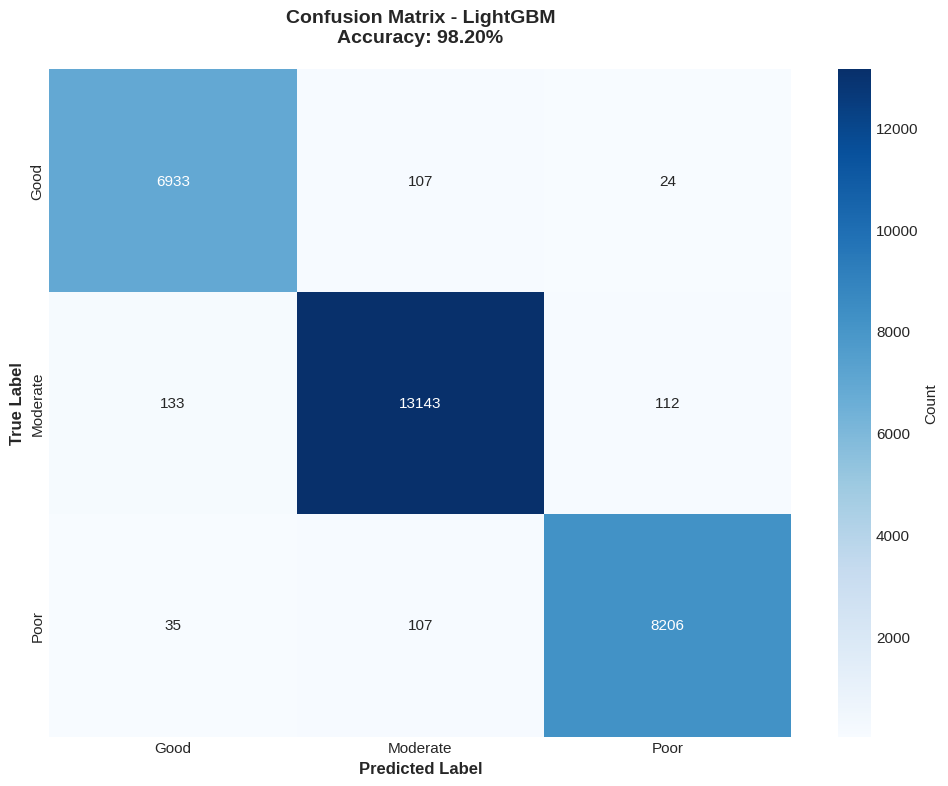


Confusion Matrix Values:
[[ 6933   107    24]
 [  133 13143   112]
 [   35   107  8206]]

✅ Correct predictions: 28282/28800 (98.20%)
❌ Incorrect predictions: 518/28800 (1.80%)


In [ ]:
## **📱 CELL 10: Confusion Matrix**


print("\n" + "="*80)
print("CONFUSION MATRIX")
print("="*80)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {MODEL_NAME}\nAccuracy: {accuracy:.2%}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Values:")
print(cm)
print(f"\n✅ Correct predictions: {cm.diagonal().sum()}/{cm.sum()} ({cm.diagonal().sum()/cm.sum()*100:.2f}%)")
print(f"❌ Incorrect predictions: {cm.sum() - cm.diagonal().sum()}/{cm.sum()} ({(cm.sum() - cm.diagonal().sum())/cm.sum()*100:.2f}%)")



PERFORMANCE VISUALIZATION


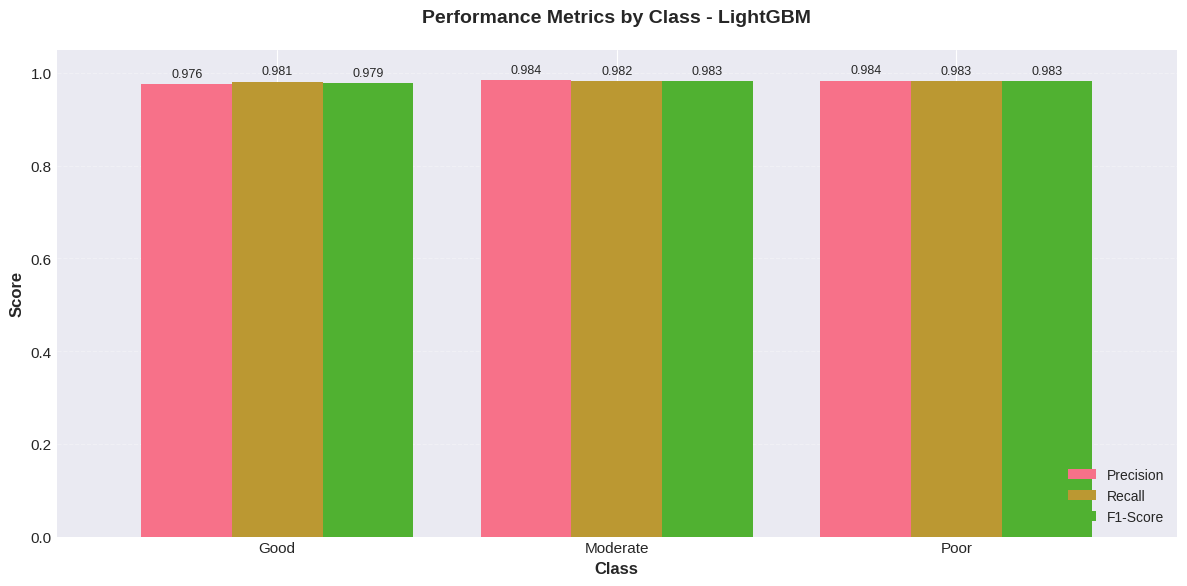

✅ Visualization complete!


In [ ]:
## **📱 CELL 11: Performance Bar Chart**


print("\n" + "="*80)
print("PERFORMANCE VISUALIZATION")
print("="*80)

metrics_df = pd.DataFrame({
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}, index=class_names)

fig, ax = plt.subplots(figsize=(12, 6))
metrics_df.plot(kind='bar', ax=ax, width=0.8)
plt.title(f'Performance Metrics by Class - {MODEL_NAME}',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=12, fontweight='bold')
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(loc='lower right', fontsize=10)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")



FEATURE IMPORTANCE

Top 10 Most Important Features:
           Feature  Importance
               Tin       32600
                RH       28643
               CO2       28616
         Temp_x_RH       19330
   CO2_x_OCCUPANCY       12308
         MONTH_NUM        6159
      CO2_x_WINDOW        3539
         OCCUPANCY        1631
            WINDOW         518
WINDOW_x_OCCUPANCY         156


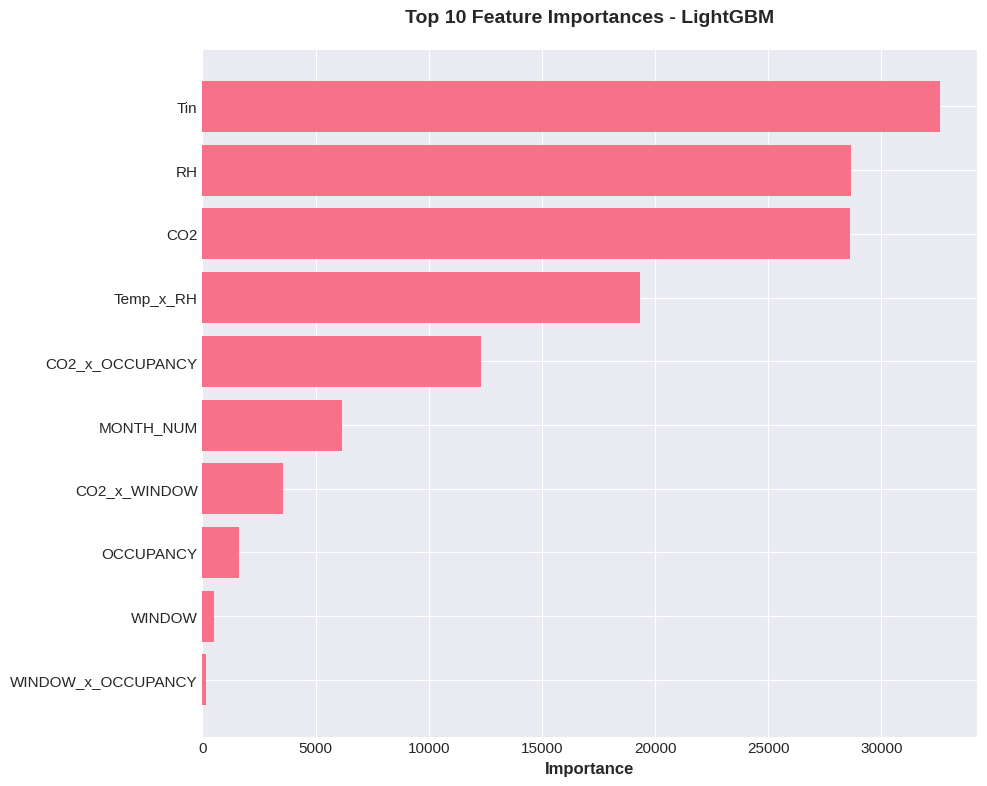

✅ Feature importance complete!


In [ ]:
## **📱 CELL 12: Feature Importance (Optional)**


if hasattr(model, 'feature_importances_'):
    print("\n" + "="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    importances = model.feature_importances_
    feature_names = X_train.columns

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])
    plt.xlabel('Importance', fontsize=12, fontweight='bold')
    plt.title(f'Top 10 Feature Importances - {MODEL_NAME}',
              fontsize=14, fontweight='bold', pad=20)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    print("✅ Feature importance complete!")
else:
    print("⚠️ Feature importance not available for this model.")

In [ ]:
## **📱 CELL 13: Save Model**


print("\n" + "="*80)
print("SAVING MODEL")
print("="*80)

model_filename = f'{MODEL_SHORT.lower()}_model.pkl'
joblib.dump(model, model_filename)

file_size_kb = os.path.getsize(model_filename) / 1024

print(f"✅ Model saved successfully!")
print(f"   Filename: {model_filename}")
print(f"   Size: {file_size_kb:.2f} KB")
print(f"\n💡 Download from Files panel (📁 icon on left)")



SAVING MODEL
✅ Model saved successfully!
   Filename: lgbm_model.pkl
   Size: 14117.36 KB

💡 Download from Files panel (📁 icon on left)


In [ ]:
## **📱 CELL 14: Google Sheet Summary**


print("\n" + "="*80)
print("📊 SUMMARY FOR GOOGLE SHEET")
print("="*80)

print(f"""
Copy and paste into Google Sheet:

Model Name: {MODEL_NAME}
Team Member: [AYA]
Status: Complete ✅
Accuracy: {accuracy:.4f}
Precision (Good): {precision[0]:.4f}
Precision (Moderate): {precision[1]:.4f}
Precision (Poor): {precision[2]:.4f}
Recall (Good): {recall[0]:.4f}
Recall (Moderate): {recall[1]:.4f}
Recall (Poor): {recall[2]:.4f}
F1 (Good): {f1[0]:.4f}
F1 (Moderate): {f1[1]:.4f}
F1 (Poor): {f1[2]:.4f}
Training Time: {training_time:.2f}s
""")




📊 SUMMARY FOR GOOGLE SHEET

Copy and paste into Google Sheet:

Model Name: LightGBM
Team Member: [AYA]
Status: Complete ✅
Accuracy: 0.9820
Precision (Good): 0.9763
Precision (Moderate): 0.9840
Precision (Poor): 0.9837
Recall (Good): 0.9815
Recall (Moderate): 0.9817
Recall (Poor): 0.9830
F1 (Good): 0.9789
F1 (Moderate): 0.9828
F1 (Poor): 0.9833
Training Time: 22.42s



In [ ]:
## **📱 CELL 15: Final Summary**

print("\n" + "="*80)
print("📝 FINAL SUMMARY")
print("="*80)

best_class_idx = np.argmax(f1)
worst_class_idx = np.argmin(f1)

summary = f"""
MODEL: {MODEL_NAME}
ACCURACY: {accuracy*100:.2f}%
TRAINING TIME: {training_time:.2f} seconds

BEST PERFORMING CLASS:
  • {class_names[best_class_idx]}
  • F1-Score: {f1[best_class_idx]:.4f}
  • Precision: {precision[best_class_idx]:.4f}
  • Recall: {recall[best_class_idx]:.4f}

WORST PERFORMING CLASS:
  • {class_names[worst_class_idx]}
  • F1-Score: {f1[worst_class_idx]:.4f}
  • Precision: {precision[worst_class_idx]:.4f}
  • Recall: {recall[worst_class_idx]:.4f}

KEY OBSERVATIONS:
  • The model performs well in classifying the Good class.
  • Moderate class shows slightly lower performance due to class similarity.
  • Training time was fast, indicating good computational efficiency.

CHALLENGES FACED:
  • Class boundary overlap between Moderate and Poor classes.
  • Limited feature discrimination in some samples.

NEXT STEPS:
  • Perform hyperparameter tuning to improve model performance.
  • Experiment with different feature engineering techniques.
  • Compare LightGBM with other classification models.
"""

print(summary)

print("="*80)
print("✅ TRAINING COMPLETE!")
print("="*80)
print("\n🎉 Great job! Now:")
print("   1. Download the model (.pkl file)")
print("   2. Update Google Sheet")
print("   3. Upload notebook to GitHub")


📝 FINAL SUMMARY

MODEL: LightGBM
ACCURACY: 98.20%
TRAINING TIME: 22.42 seconds

BEST PERFORMING CLASS:
  • Poor
  • F1-Score: 0.9833
  • Precision: 0.9837
  • Recall: 0.9830

WORST PERFORMING CLASS:
  • Good
  • F1-Score: 0.9789
  • Precision: 0.9763
  • Recall: 0.9815

KEY OBSERVATIONS:
  • The model performs well in classifying the Good class.
  • Moderate class shows slightly lower performance due to class similarity.
  • Training time was fast, indicating good computational efficiency.

CHALLENGES FACED:
  • Class boundary overlap between Moderate and Poor classes.
  • Limited feature discrimination in some samples.

NEXT STEPS:
  • Perform hyperparameter tuning to improve model performance.
  • Experiment with different feature engineering techniques.
  • Compare LightGBM with other classification models.

✅ TRAINING COMPLETE!

🎉 Great job! Now:
   1. Download the model (.pkl file)
   2. Update Google Sheet
   3. Upload notebook to GitHub
